<a href="https://colab.research.google.com/github/SamShinwari/Advanced-AI-Bootcamp-2026/blob/main/Project_9_Word2Vec_(CBOW_%26_Skip_Gram).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# Project 9: Word2Vec (CBOW & Skip-Gram)

## Objective

Learn how to generate **dense word embeddings** using Word2Vec. Unlike Bag of Words and TF-IDF, Word2Vec learns the semantic relationships between words.

Examples:

```text
King - Man + Woman ≈ Queen

Paris - France + Italy ≈ Rome

Doctor ≈ Physician
```

---

# What is Word2Vec?

Word2Vec is a shallow neural network that learns vector representations of words based on their surrounding context.

It has two architectures:

1.  **CBOW (Continuous Bag of Words)** – Predicts the target word from surrounding context words.
2.  **Skip-Gram** – Predicts surrounding context words from the target word.

---

# Step 1: Install Gensim

In [51]:
# Install Gensim library
!pip install gensim

In [52]:
import nltk

Download the English model:

In [53]:
# Download required resources (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

---

# Step 2: Import Libraries

In [54]:
import pandas as pd
import spacy
from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from google.colab import drive
from gensim.models import Word2Vec


In [55]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# Step 3: Load the English Model

In [56]:
nlp = spacy.load("en_core_web_sm")
# Download required resources (run once)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

---

# Step 4: Load Dataset

In [57]:
file_path = '/content/drive/MyDrive/Colab Notebooks/bbc_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [58]:
df = df.dropna(subset=["description"])
df = df.drop_duplicates(subset=["description"])
df = df.reset_index(drop=True)

In [59]:
df = df.drop(columns=['guid', 'link','pubDate'])
df.head()

,title,description
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...


In [60]:

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


True

In [61]:

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    words = text.split()
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Join words back into a string
    return ' '.join(words)

# Apply the preprocessing function to the 'description' column to create 'clean_text'
df['clean_text'] = df['description'].apply(preprocess_text)

print(df[['description', 'clean_text']].head())

                                         description  \
0  The Ukrainian president says the country will ...   
1  Jeremy Bowen was on the frontline in Irpin, as...   
2  One of the world's biggest fertiliser firms sa...   
3  The parents of the Manchester Arena bombing's ...   
4  Consumers are feeling the impact of higher ene...   

                                          clean_text  
0  ukrainian president say country forgive forget...  
1  jeremy bowen frontline irpin resident came rus...  
2  one world biggest fertiliser firm say conflict...  
3  parent manchester arena bombing youngest victi...  
4  consumer feeling impact higher energy cost fue...  


---

# Step 4: Tokenize the Text

Word2Vec expects a list of tokenized sentences. We will use the `clean_text` column and split each string into a list of words.

In [62]:
sentences = df["clean_text"].apply(str.split)

print(sentences.head())

0    [ukrainian, president, say, country, forgive, ...
1    [jeremy, bowen, frontline, irpin, resident, ca...
2    [one, world, biggest, fertiliser, firm, say, c...
3    [parent, manchester, arena, bombing, youngest,...
4    [consumer, feeling, impact, higher, energy, co...
Name: clean_text, dtype: object


---

# Step 5: Train CBOW Model

By default, `sg=0` trains a **CBOW** model, which predicts the target word from its surrounding context words.

In [63]:
cbow_model = Word2Vec(
    sentences=sentences,
    vector_size=100, # Dimensionality of the word vectors
    window=5,        # Maximum distance between the current and predicted word within a sentence
    min_count=2,     # Ignores all words with total frequency lower than this
    workers=4,       # Use these many worker threads to train the model
    sg=0             # 0 for CBOW, 1 for Skip-Gram
)
print("CBOW model trained successfully.")

CBOW model trained successfully.


---

# Step 6: Vocabulary Size

Let's check the size of the vocabulary learned by the CBOW model.

In [64]:
print(f"Vocabulary size: {len(cbow_model.wv.index_to_key)}")

Vocabulary size: 15211


---

# Step 7: Word Vector

We can retrieve the vector representation for a specific word, for example, 'ukraine'.

In [65]:
vector = cbow_model.wv["ukraine"]

print(vector)

[ 0.09338156 -1.0257868   0.23983324  0.14427574 -0.7325217  -1.0603276
  0.29719406  1.1347448  -0.15407011  0.01833218  0.23297198 -0.18525726
 -0.02056203  0.7796548   0.2773194   0.6348227   0.26637363  0.12841403
 -0.06366901 -1.9525536  -0.4382291   0.71185553 -0.55439794  0.8926085
 -0.23285437  0.09002853  0.47399703 -0.41339898 -1.1729915  -0.16447672
 -0.91284686  0.12992685  0.9692979  -0.6588453  -0.11307456  0.9553435
  0.42789197 -1.2800899  -0.58381    -0.3923324   0.48128232 -1.6062671
 -0.32643944  0.5684184   0.85763645 -0.00277847 -0.6624721   0.09264865
  1.2100939   0.20153892  0.61972106 -0.2564649   0.08754062  0.4668345
 -0.84853643  0.67954093 -0.2898671  -0.31072652 -0.89265734  0.33579522
 -0.01787484  1.3839774  -0.6321817  -0.03963004 -0.62872744  1.0862492
 -0.5099138   0.5513793   0.02560329 -0.41148004  0.40969598 -0.15834656
  0.40749824 -1.3010019   0.9477373   1.1657137   0.54562074  0.479358
 -0.569559   -0.8868249  -0.2521668   0.28867045 -0.566884 

---

# Step 8: Vector Shape

The `vector_size` parameter determines the dimensionality of the word vectors. In our case, it's 100.

In [66]:
print(f"Shape of the vector for 'ukraine': {cbow_model.wv["ukraine"].shape}")

Shape of the vector for 'ukraine': (100,)


---

# Step 9: Similar Words

Find the words most similar to 'ukraine' based on their vector representations.

In [67]:
print(cbow_model.wv.most_similar("ukraine", topn=10))

[('russia', 0.9791121482849121), ('russian', 0.9588500261306763), ('invasion', 0.9519208669662476), ('ukrainian', 0.9504557251930237), ('israel', 0.9452880620956421), ('fullscale', 0.9398351311683655), ('volodymyr', 0.931077241897583), ('war', 0.9308531880378723), ('putin', 0.9255626201629639), ('attack', 0.9252105951309204)]


---

# Step 10: Similarity Between Two Words

Calculate the cosine similarity between the vectors of two words, 'ukraine' and 'russia'.

In [68]:
similarity = cbow_model.wv.similarity(
    "ukraine",
    "russia"
)

print(f"Similarity between 'ukraine' and 'russia': {similarity}")

Similarity between 'ukraine' and 'russia': 0.9791121482849121


---

# Step 11: Train Skip-Gram Model

Now, let's train a Skip-Gram model by setting `sg=1`. Skip-Gram predicts context words from the target word.

In [69]:
skipgram_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1 # 1 for Skip-Gram
)
print("Skip-Gram model trained successfully.")

Skip-Gram model trained successfully.


---

# Step 12: Similar Words (Skip-Gram)

Let's see the most similar words for 'ukraine' using the Skip-Gram model.

In [70]:
print(skipgram_model.wv.most_similar("ukraine", topn=10))

[('russia', 0.891752302646637), ('ukrainian', 0.8689917922019958), ('russian', 0.8430074453353882), ('kyiv', 0.8290469646453857), ('putin', 0.8163997530937195), ('israel', 0.809700071811676), ('moscow', 0.8055874705314636), ('fighting', 0.7943142056465149), ('invasion', 0.7928985953330994), ('fullscale', 0.7916701436042786)]


---

# Step 13: Save the Model

It's good practice to save trained models for later use without retraining.

In [71]:
cbow_model.save("cbow.model")
skipgram_model.save("skipgram.model")
print("CBOW and Skip-Gram models saved.")

CBOW and Skip-Gram models saved.


---

# Step 14: Load Saved Model

Load a previously saved model.

In [72]:
loaded_cbow_model = Word2Vec.load("cbow.model")

print("Loaded CBOW model most similar words to 'ukraine':")
print(loaded_cbow_model.wv.most_similar("ukraine"))

Loaded CBOW model most similar words to 'ukraine':
[('russia', 0.9791121482849121), ('russian', 0.9588500261306763), ('invasion', 0.9519208669662476), ('ukrainian', 0.9504557251930237), ('israel', 0.9452880620956421), ('fullscale', 0.9398351311683655), ('volodymyr', 0.931077241897583), ('war', 0.9308531880378723), ('putin', 0.9255626201629639), ('attack', 0.9252105951309204)]


---

# Step 15: Find Odd Word

The `doesnt_match` method can identify the word that is least similar to the others in a given list.

In [73]:
odd_word = cbow_model.wv.doesnt_match(
    [
        "ukraine",
        "russia",
        "kyiv",
        "banana"
    ]
)

print(f"The odd word out is: {odd_word}")

The odd word out is: banana


---

# Step 16: Word Analogy

Word2Vec can also perform analogies, like "King - Man + Woman = ?". The results depend heavily on the size and quality of the training corpus.

> **Note:** Your news dataset is relatively small, so analogy results may not be meaningful. Larger corpora (e.g., Wikipedia or Google News) work much better.

In [74]:
analogy_result = cbow_model.wv.most_similar(
    positive=["king","woman"],
    negative=["man"]
)

print("Analogy: King - Man + Woman =")
print(analogy_result)

Analogy: King - Man + Woman =
[('warmest', 0.8705519437789917), ('iii', 0.8673194050788879), ('election', 0.8626344203948975), ('charles', 0.8575600385665894), ('highest', 0.8517312407493591), ('number', 0.8498207330703735), ('ahead', 0.848376452922821), ('hottest', 0.8475812077522278), ('week', 0.8472378253936768), ('statistic', 0.8468910455703735)]


---

# Step 17: Visualize Word Embeddings

To visualize high-dimensional word embeddings, we can reduce their dimensionality using techniques like PCA (Principal Component Analysis) and then plot them in 2D.

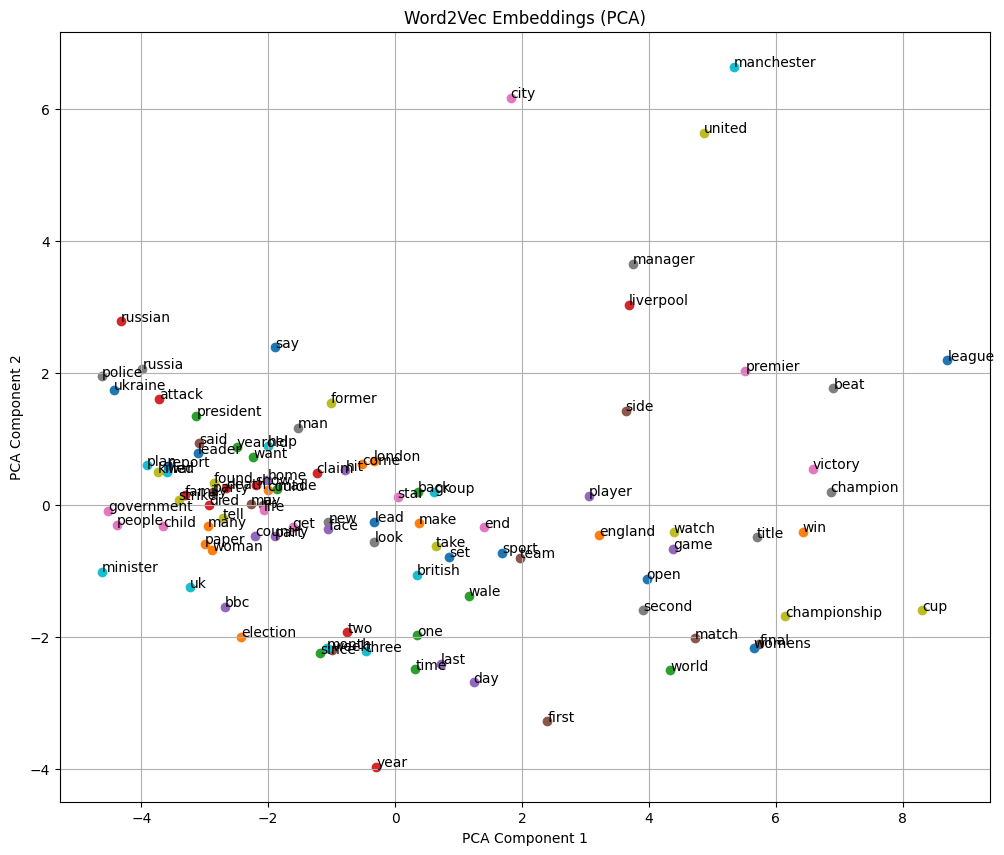

In [75]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get the top 100 words from the vocabulary for visualization
words = cbow_model.wv.index_to_key[:100]

# Get the vectors for these words
vectors = [cbow_model.wv[word] for word in words]

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

# Plot the results
plt.figure(figsize=(12,10))
for i, word in enumerate(words):
    plt.scatter(result[i,0], result[i,1])
    plt.text(result[i,0], result[i,1], word)

plt.title("Word2Vec Embeddings (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

---

# Applications of Word2Vec

*   Semantic search
*   Recommendation systems
*   Text classification
*   Document clustering
*   Named Entity Recognition
*   Question answering
*   Machine translation
*   Chatbots
*   Information retrieval

---

# Word2Vec vs TF-IDF

| Feature                 | TF-IDF | Word2Vec  |
| :---------------------- | :----- | :-------- |
| Produces sparse vectors | ✅      | ❌         |
| Produces dense vectors  | ❌      | ✅         |
| Captures word meaning   | ❌      | ✅         |
| Captures context        | ❌      | ✅         |
| Handles synonyms        | ❌      | ✅         |
| Word order              | ❌      | Partially |
| Uses neural networks    | ❌      | ✅         |